In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/global_supply_chain_risk_2026.csv')

In [3]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek

In [6]:
df = df.drop('Date', axis=1)

In [7]:
df.head()

,Shipment_ID,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,year,month,day_of_week
0,SC-10000,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,2025,10,3
1,SC-10001,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,2024,4,2
2,SC-10002,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,2024,1,4
3,SC-10003,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,2024,10,1
4,SC-10004,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,2024,9,5


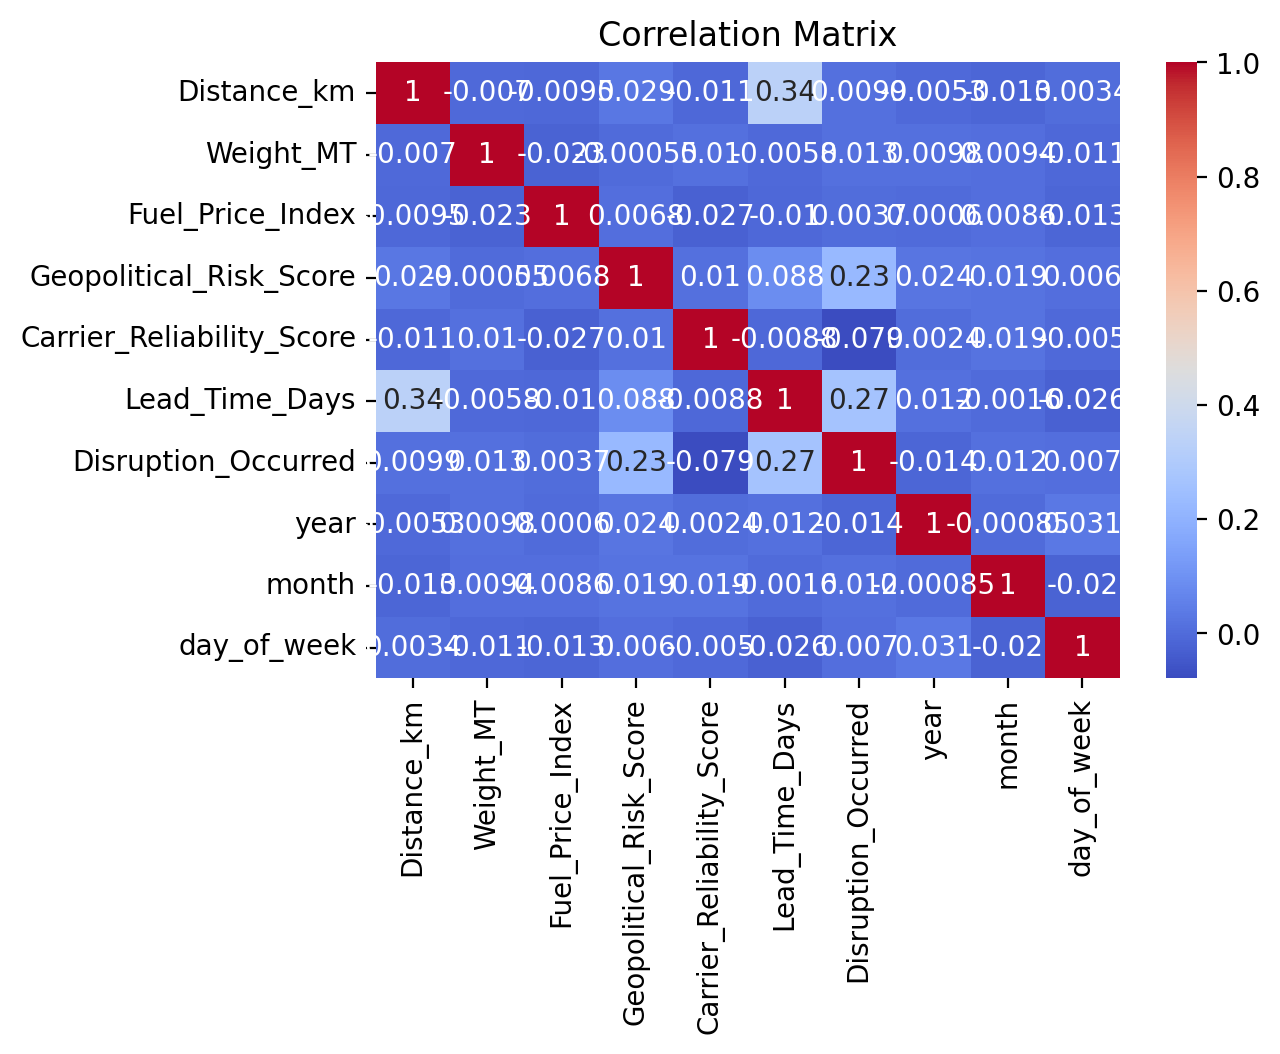

In [8]:
plt.figure(figsize=(6,4), dpi=200)
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [11]:
cat_cols_id = cat_cols.pop(0)

In [12]:
cat_cols

['Origin_Port',
 'Destination_Port',
 'Transport_Mode',
 'Product_Category',
 'Weather_Condition']

In [13]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [14]:
df.head()

,Shipment_ID,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,year,month,...,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm
0,SC-10000,5930.83,197.42,2.43,5.0,0.865,41.39,1,2025,10,...,False,False,False,False,False,True,False,True,False,False
1,SC-10001,14285.36,237.24,2.30,7.5,0.592,40.92,1,2024,4,...,False,False,False,False,False,False,False,False,False,True
2,SC-10002,11113.91,427.42,1.78,5.6,0.673,11.54,0,2024,1,...,False,False,False,True,False,False,False,False,True,False
3,SC-10003,9180.55,170.66,3.20,0.8,0.832,53.13,1,2024,10,...,False,False,True,False,False,False,False,True,False,False
4,SC-10004,2762.27,434.96,2.77,1.9,0.741,0.50,1,2024,9,...,False,False,False,True,False,False,True,False,False,False


In [15]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

In [16]:
df.head()

,Shipment_ID,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,year,month,...,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm
0,SC-10000,5930.83,197.42,2.43,5.0,0.865,41.39,1,2025,10,...,0,0,0,0,0,1,0,1,0,0
1,SC-10001,14285.36,237.24,2.30,7.5,0.592,40.92,1,2024,4,...,0,0,0,0,0,0,0,0,0,1
2,SC-10002,11113.91,427.42,1.78,5.6,0.673,11.54,0,2024,1,...,0,0,0,1,0,0,0,0,1,0
3,SC-10003,9180.55,170.66,3.20,0.8,0.832,53.13,1,2024,10,...,0,0,1,0,0,0,0,1,0,0
4,SC-10004,2762.27,434.96,2.77,1.9,0.741,0.50,1,2024,9,...,0,0,0,1,0,0,1,0,0,0


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
df.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,year,month,day_of_week,...,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600,2024.509000,6.564400,3.044400,...,0.242800,0.256200,0.20320,0.201800,0.201200,0.202000,0.207200,0.198000,0.195400,0.20040
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205,0.499969,3.463387,1.999707,...,0.428818,0.436577,0.40242,0.401384,0.400937,0.401532,0.405341,0.398532,0.396548,0.40034
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000,2024.000000,1.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000,2024.000000,4.000000,1.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000,2025.000000,7.000000,3.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000,2025.000000,10.000000,5.000000,...,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000,2025.000000,12.000000,6.000000,...,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 37 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Shipment_ID                       5000 non-null   object 
 1   Distance_km                       5000 non-null   float64
 2   Weight_MT                         5000 non-null   float64
 3   Fuel_Price_Index                  5000 non-null   float64
 4   Geopolitical_Risk_Score           5000 non-null   float64
 5   Carrier_Reliability_Score         5000 non-null   float64
 6   Lead_Time_Days                    5000 non-null   float64
 7   Disruption_Occurred               5000 non-null   int64  
 8   year                              5000 non-null   int32  
 9   month                             5000 non-null   int32  
 10  day_of_week                       5000 non-null   int32  
 11  Origin_Port_Busan                 5000 non-null   int64  
 12  Origin

<Axes: xlabel='Disruption_Occurred', ylabel='count'>

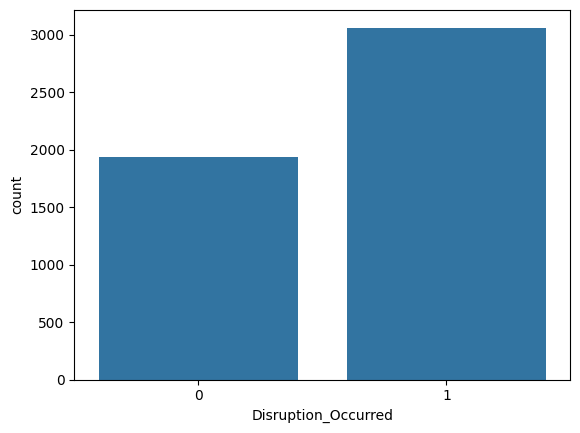

In [20]:
sns.countplot(data=df, x='Disruption_Occurred')

In [21]:
drop_cols = ['Shipment_ID', 'Disruption_Occurred']

In [22]:
X = df.drop(drop_cols, axis=1)
y = df['Disruption_Occurred']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, random_state=42)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

selector = Pipeline([
    ('variance', VarianceThreshold(threshold=0.01)),  
    ('kbest', SelectKBest(f_classif, k=6))          
])

selector.fit(X_train, y_train)

X_train_filtered = selector.transform(X_train)
X_test_filtered = selector.transform(X_test)
X = selector.transform(X)

In [29]:
variance_mask = selector['variance'].get_support()
kbest_mask = selector['kbest'].get_support()

features_after_variance = X_train.columns[variance_mask]
good_features = features_after_variance[kbest_mask].tolist()
print(good_features)

['Geopolitical_Risk_Score', 'Lead_Time_Days', 'Weather_Condition_Fog', 'Weather_Condition_Hurricane', 'Weather_Condition_Rain', 'Weather_Condition_Storm']


In [30]:
from sklearn.model_selection import cross_val_score

def objective(trial):
    model_name = trial.suggest_categorical("model", ["logreg", "rf", "xgb"])

    # ================= LOGISTIC REGRESSION =================
    if model_name == "logreg":
        penalty = trial.suggest_categorical(
            "logreg_penalty", ["l1", "l2", "elasticnet"]
        )
        
        solver = trial.suggest_categorical(
            "logreg_solver", ["lbfgs", "liblinear", "saga"]
        )
        
        if penalty == "elasticnet" and solver != "saga":
            raise optuna.exceptions.TrialPruned()
        
        if penalty == "l1" and solver not in ["liblinear", "saga"]:
            raise optuna.exceptions.TrialPruned()
        
        params = {
            "C": trial.suggest_float("logreg_C", 0.01, 10.0, log=True),
            "penalty": penalty,
            "solver": solver,
            "max_iter": trial.suggest_int("logreg_max_iter", 100, 1000),
        }
        
        if penalty == "elasticnet":
            params["l1_ratio"] = trial.suggest_float(
                "logreg_l1_ratio", 0.0, 1.0
            )

        model = LogisticRegression(**params)

        steps = [
            ("scaler", StandardScaler()),
            ("model", model),
        ]

    # ================= RANDOM FOREST =================
    elif model_name == "rf":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n_estimators", 100, 500),
            max_depth=trial.suggest_int("rf_max_depth", 3, 20),
            min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 10),
            n_jobs=-1,
            random_state=42,
        )

        steps = [
            ("model", model),
        ]

    # ================= XGBOOST =================
    else:
        model = XGBClassifier(
            n_estimators=trial.suggest_int("xgb_n_estimators", 100, 500),
            max_depth=trial.suggest_int("xgb_max_depth", 3, 10),
            learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.3, log=True),
            subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("xgb_colsample", 0.5, 1.0),
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1,
            random_state=42,
            tree_method="hist",
        )

        steps = [
            ("model", model),
        ]

    pipeline = Pipeline(steps)


    score = cross_val_score(
        pipeline,
        X,
        y,
        cv=8,
        scoring="roc_auc",
        n_jobs=-1,
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150)

print("Best params:", study.best_trial.params)
print("Best score:", study.best_value)

[I 2026-03-21 18:51:33,458] A new study created in memory with name: no-name-8b09c8f0-e1aa-4361-936b-e3e9262e739d
[I 2026-03-21 18:51:41,812] Trial 0 finished with value: 0.8106851572676823 and parameters: {'model': 'xgb', 'xgb_n_estimators': 249, 'xgb_max_depth': 8, 'xgb_lr': 0.013706866123046292, 'xgb_subsample': 0.6465992362015002, 'xgb_colsample': 0.5722418447905661}. Best is trial 0 with value: 0.8106851572676823.
[I 2026-03-21 18:51:42,196] Trial 1 finished with value: 0.8040361234081532 and parameters: {'model': 'xgb', 'xgb_n_estimators': 136, 'xgb_max_depth': 9, 'xgb_lr': 0.045989270664783984, 'xgb_subsample': 0.61625607229594, 'xgb_colsample': 0.6186296665640476}. Best is trial 0 with value: 0.8106851572676823.
[I 2026-03-21 18:51:44,667] Trial 2 finished with value: 0.8104460067397214 and parameters: {'model': 'rf', 'rf_n_estimators': 275, 'rf_max_depth': 11, 'rf_min_samples_split': 9}. Best is trial 0 with value: 0.8106851572676823.
[I 2026-03-21 18:51:47,214] Trial 3 finish

Best params: {'model': 'logreg', 'logreg_penalty': 'l1', 'logreg_solver': 'saga', 'logreg_C': 0.15167418777222713, 'logreg_max_iter': 894}
Best score: 0.8280255379536591


In [31]:
model = LogisticRegression(penalty='l1', solver='saga', C=0.15167418777222713, max_iter=894)

In [33]:
model.fit(X_train_filtered, y_train)

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.15167418777222713
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,894
,multi_class,'deprecated'


In [34]:
y_pred = model.predict(X_test_filtered)

In [35]:
from sklearn.metrics import classification_report

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.63      0.66       236
           1       0.77      0.82      0.79       364

    accuracy                           0.74       600
   macro avg       0.73      0.72      0.73       600
weighted avg       0.74      0.74      0.74       600



In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

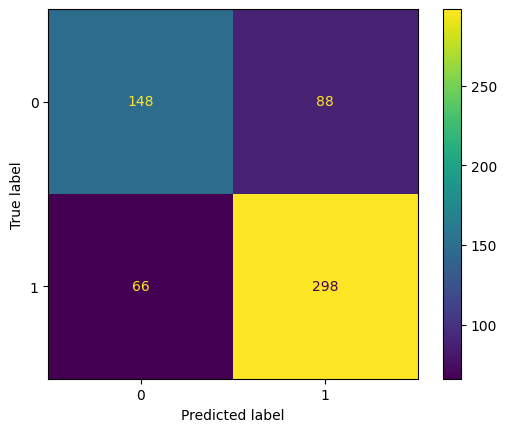

In [39]:
ConfusionMatrixDisplay.from_estimator(model, X_test_filtered, y_test)

In [44]:
X_train_filtered = pd.DataFrame(X_train_filtered)
X_test_filtered = pd.DataFrame(X_test_filtered)

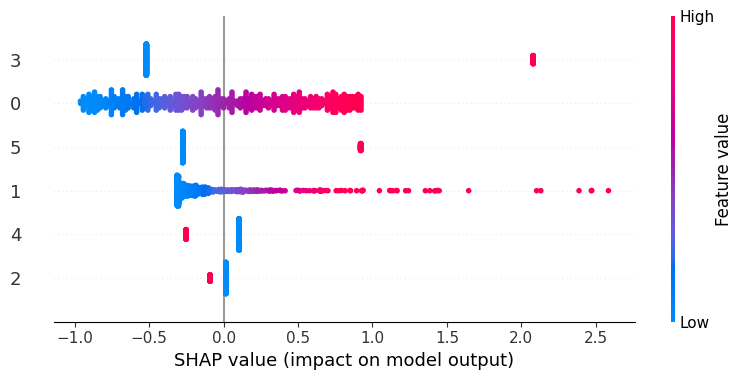

In [46]:
import shap

explainer = shap.Explainer(model, X_train_filtered)
shap_values = explainer(X_test_filtered)
shap.summary_plot(shap_values, X_test_filtered)